# Predictive Maintenance — Binary Classification Pipeline

**Задача:** Определить вышел ли станок ЧПУ из строя (Target: 0 — норма, 1 — отказ)

**Этапы:**
1. Feature Engineering
2. Подготовка данных
3. Train/Test split
4. StandardScaler
5. Borderline-SMOTE 2
6. Обучение моделей (LR, SVM, LDA)
7. cross_val_score
8. GridSearchCV
9. Оценка на test
10. Сохранение модели

## Этап 1. Feature Engineering

In [2]:
import pandas as pd

df = pd.read_csv('dataset/predictive_maintenance_clean.csv')

print(f'Загружено строк: {len(df)}')
print(f'Столбцов: {len(df.columns)}')
df.head(3)

Загружено строк: 9973
Столбцов: 10


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure


In [3]:
# Признак 1: разница температур — отражает тепловой баланс станка
# Сами по себе температуры коррелируют между собой (мультиколлинеарность)
# Разница несёт физический смысл: сколько тепла накопил станок сверх внешней среды
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Признак 2: механическая мощность P = ω × M
# Скорость и момент по отдельности дают противоречивые сигналы при отказе
# Их произведение — реальная нагрузка на механизм
df['power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

# Признак 3: накопленная усталость под нагрузкой
# Высокий износ при высоком моменте — комбинированный риск отказа
df['tool_wear_torque'] = df['Tool wear [min]'] * df['Torque [Nm]']

print('Новые признаки созданы:')
print(df[['temp_diff', 'power', 'tool_wear_torque']].describe().round(2))

Новые признаки созданы:
       temp_diff     power  tool_wear_torque
count     9973.0   9973.00           9973.00
mean        10.0  59958.79           4312.96
std          1.0  10189.30           2826.17
min          7.6  10966.80              0.00
25%          9.3  53111.00           1963.70
50%          9.8  59866.20           4006.80
75%         11.0  66859.00           6276.40
max         12.1  99980.40          16497.00


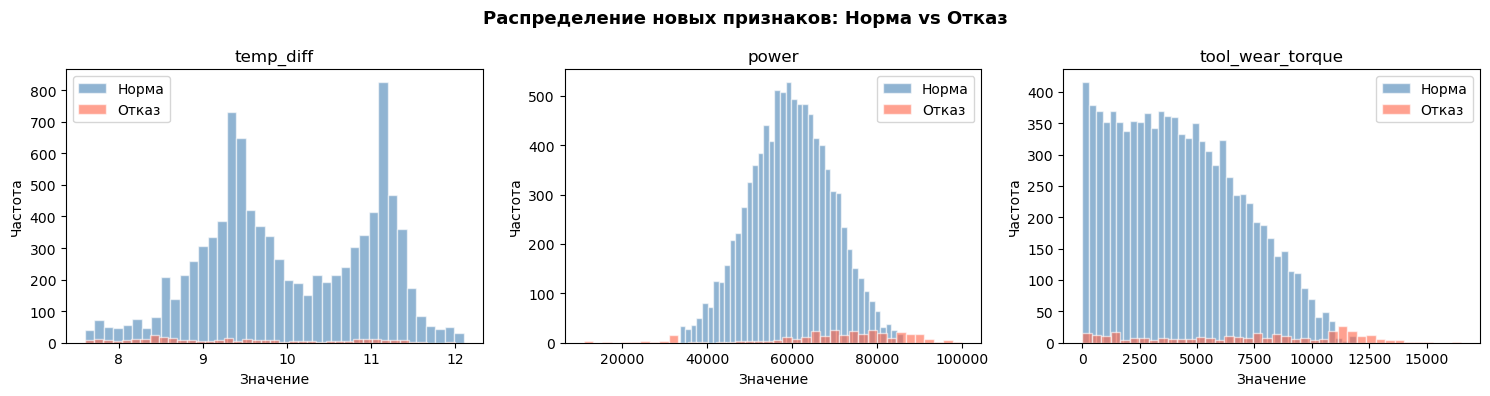

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

new_features = ['temp_diff', 'power', 'tool_wear_torque']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(new_features):
    for target, color, label in [(0, 'steelblue', 'Норма'), (1, 'tomato', 'Отказ')]:
        subset = df[df['Target'] == target][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    axes[i].legend()

plt.suptitle('Распределение новых признаков: Норма vs Отказ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Проверяем насколько новые признаки коррелируют с Target
all_features = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
    'temp_diff', 'power', 'tool_wear_torque'
]

corr_with_target = (
    df[all_features + ['Target']]
    .corr()['Target']
    .drop('Target')
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print('Корреляция признаков с Target (по модулю, убывание):')
print(corr_with_target.to_string())

Корреляция признаков с Target (по модулю, убывание):
Torque [Nm]                0.1934
tool_wear_torque           0.1927
power                      0.1780
temp_diff                 -0.1126
Tool wear [min]            0.1063
Air temperature [K]        0.0831
Rotational speed [rpm]    -0.0440
Process temperature [K]    0.0360


## Этап 2. Подготовка данных

In [6]:
# Удаляем нерелевантные столбцы:
# UDI, Product ID — идентификаторы, не несут предсказательной силы
# Failure Type — целевая для мультиклассовой задачи, здесь утечка данных
# Air temperature, Process temperature — заменены на temp_diff (убираем мультиколлинеарность)
cols_to_drop = [
    'UDI', 'Product ID', 'Failure Type',
    'Air temperature [K]', 'Process temperature [K]'
]

df = df.drop(columns=cols_to_drop)

print('Столбцы после удаления:')
print(df.columns.tolist())

Столбцы после удаления:
['Type', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'temp_diff', 'power', 'tool_wear_torque']


In [7]:
# Кодируем категориальный признак Type (L / M / H)
# One-Hot Encoding: drop_first=True убирает одну колонку во избежание мультиколлинеарности
# L → Type_M=0, Type_H=0 | M → Type_M=1, Type_H=0 | H → Type_M=0, Type_H=1
df = pd.get_dummies(df, columns=['Type'], drop_first=True, dtype=int)

print('Столбцы после One-Hot Encoding:')
print(df.columns.tolist())
print(f'\nИтоговая форма датасета: {df.shape}')
df.head(3)

Столбцы после One-Hot Encoding:
['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'temp_diff', 'power', 'tool_wear_torque', 'Type_L', 'Type_M']

Итоговая форма датасета: (9973, 9)


,Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,temp_diff,power,tool_wear_torque,Type_L,Type_M
0,1551,42.8,0,0,10.5,66382.8,0.0,0,1
1,1408,46.3,3,0,10.5,65190.4,138.9,1,0
2,1498,49.4,5,0,10.4,74001.2,247.0,1,0


In [8]:
# Финальная проверка перед разбивкой
print('Распределение целевой переменной:')
counts = df['Target'].value_counts()
for val, cnt in counts.items():
    label = 'Норма' if val == 0 else 'Отказ'
    print(f'  {label} ({val}): {cnt} строк ({cnt / len(df) * 100:.1f}%)')

print(f'\nПропусков: {df.isnull().sum().sum()}')
print(f'Признаков для обучения: {df.shape[1] - 1}')

Распределение целевой переменной:
  Норма (0): 9643 строк (96.7%)
  Отказ (1): 330 строк (3.3%)

Пропусков: 0
Признаков для обучения: 8


## Этап 3. Train / Validation / Test split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Target'])
y = df['Target']

# Разбивка на 3 части: 70% train / 15% val / 15% test
#
# Зачем три части:
#   Train      — на этих данных модель обучается
#   Validation — на этих данных подбираем гиперпараметры (GridSearchCV)
#                и сравниваем модели между собой (cross_val_score считается на train,
#                но финальный выбор модели делается по val)
#   Test       — касаемся ТОЛЬКО ОДИН РАЗ в самом конце, чтобы получить
#                честную оценку того как модель работает на полностью новых данных
#
# Если использовать только train/test — есть риск подогнать гиперпараметры
# под test и получить завышенную оценку качества (data leakage через выбор модели)
#
# stratify=y — сохраняем пропорции классов (96.6% / 3.4%) в каждой части
# random_state=42 — воспроизводимость результатов

# Шаг 1: отделяем test (15%) от остального (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Шаг 2: из оставшихся 85% отделяем val (15% от общего ≈ 17.6% от temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=round(0.15 / 0.85, 4),
    stratify=y_temp,
    random_state=42
)

print(f'Train:      {X_train.shape[0]} строк ({X_train.shape[0] / len(df) * 100:.1f}%)')
print(f'Validation: {X_val.shape[0]} строк ({X_val.shape[0] / len(df) * 100:.1f}%)')
print(f'Test:       {X_test.shape[0]} строк ({X_test.shape[0] / len(df) * 100:.1f}%)')
print(f'\nВсего признаков: {X_train.shape[1]}')

Train:      6980 строк (70.0%)
Validation: 1497 строк (15.0%)
Test:       1496 строк (15.0%)

Всего признаков: 8


In [10]:
# Проверяем что пропорции классов сохранились в каждой части (stratify сработал)
for name, y_part in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    failures = y_part.sum()
    total = len(y_part)
    print(f'{name:12} — Отказов: {failures:3d} ({failures / total * 100:.1f}%)  |  Нормы: {total - failures:4d} ({(total - failures) / total * 100:.1f}%)')

Train        — Отказов: 231 (3.3%)  |  Нормы: 6749 (96.7%)
Validation   — Отказов:  49 (3.3%)  |  Нормы: 1448 (96.7%)
Test         — Отказов:  50 (3.3%)  |  Нормы: 1446 (96.7%)


## Этап 4. StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

# StandardScaler приводит каждый признак к среднему=0 и std=1:
#   z = (x - mean) / std
#
# Зачем это нужно:
#   Признаки имеют разные масштабы — Rotational speed [1168–2886 rpm]
#   против temp_diff [7.6–12.1 K]. SVM и LDA чувствительны к масштабу:
#   признак с большими числами будет доминировать над мелким просто из-за единиц измерения.
#   После StandardScaler все признаки вносят вклад на равных условиях.
#
# Почему fit ТОЛЬКО на train:
#   Если fit на всём датасете — mean и std будут посчитаны с учётом val и test.
#   Модель косвенно "узнает" информацию из будущих данных — это data leakage.
#   В production scaler тоже будет знать только то, что видел на train.
#
# Type_M, Type_L (бинарные 0/1) — масштабирование им не вредит,
# просто смещает к [-0.2, 4.8] — модель это корректно обрабатывает.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform на train
X_val_scaled   = scaler.transform(X_val)          # только transform — используем mean/std от train
X_test_scaled  = scaler.transform(X_test)         # только transform — используем mean/std от train

print('Масштабирование выполнено.')
print(f'\nСредние по train (должны быть ~0 после scaling):')
import numpy as np
print(np.round(X_train_scaled.mean(axis=0), 4))
print(f'\nСтд. отклонения по train (должны быть ~1 после scaling):')
print(np.round(X_train_scaled.std(axis=0), 4))

Масштабирование выполнено.

Средние по train (должны быть ~0 после scaling):
[ 0.  0. -0. -0.  0. -0.  0.  0.]

Стд. отклонения по train (должны быть ~1 после scaling):
[1. 1. 1. 1. 1. 1. 1. 1.]


## Этап 5. Borderline-SMOTE 2

In [12]:
from imblearn.over_sampling import BorderlineSMOTE

# Borderline-SMOTE 2 применяется ТОЛЬКО на train — никогда на val и test.
#
# Почему только на train:
#   Val и test должны отражать реальное распределение данных (96.6% / 3.4%).
#   Если применить SMOTE на val/test — мы оцениваем модель на синтетических данных,
#   а не на реальных. Метрики будут завышены и не отразят поведение в production.
#
# Почему Borderline-SMOTE 2, а не обычный SMOTE:
#   Обычный SMOTE генерирует синтетику равномерно по всему minority-классу,
#   включая точки далеко от границы — это добавляет шум.
#   Borderline-SMOTE 2 генерирует синтетику только для "опасных" точек на границе,
#   причём второй конец отрезка может быть из majority-класса (с λ до 0.5) —
#   синтетика появляется прямо в зоне смешения классов, где модель ошибается чаще всего.
#   Наш датасет имеет сильно перекрывающиеся распределения → вариант 2 оптимален.
#
# kind='borderline-2' — вариант с синтетикой в зоне смешения классов
# k_neighbors=5       — стандартное число соседей для построения отрезков
# random_state=42     — воспроизводимость

smote = BorderlineSMOTE(kind='borderline-2', k_neighbors=5, sampling_strategy=0.3, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('До Borderline-SMOTE 2:')
print(f'  Норма:  {(y_train == 0).sum()}')
print(f'  Отказ:  {(y_train == 1).sum()}')
print(f'\nПосле Borderline-SMOTE 2:')
print(f'  Норма:  {(y_train_res == 0).sum()}')
print(f'  Отказ:  {(y_train_res == 1).sum()}')
print(f'\nВсего строк в train: {len(y_train_res)}')

До Borderline-SMOTE 2:
  Норма:  6749
  Отказ:  231

После Borderline-SMOTE 2:
  Норма:  6749
  Отказ:  2024

Всего строк в train: 8773


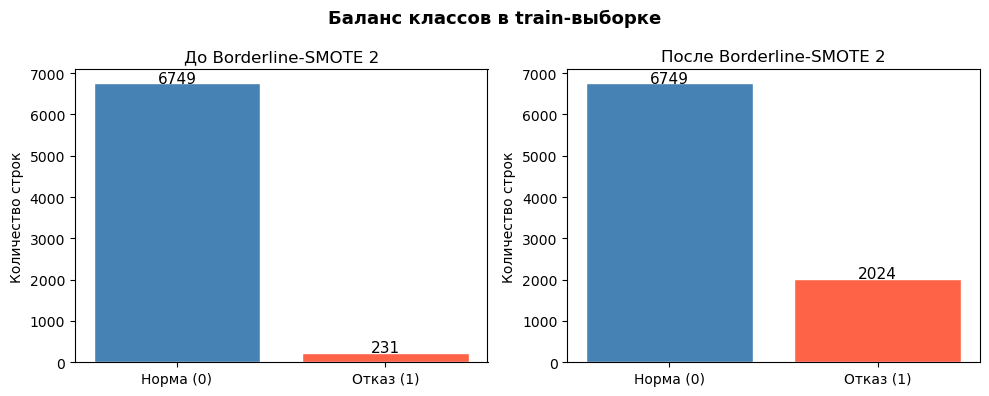

In [13]:
import matplotlib.pyplot as plt

# Визуализируем баланс классов до и после SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, counts, title in [
    (axes[0], [( y_train == 0).sum(),  (y_train == 1).sum()],     'До Borderline-SMOTE 2'),
    (axes[1], [(y_train_res == 0).sum(), (y_train_res == 1).sum()], 'После Borderline-SMOTE 2'),
]:
    bars = ax.bar(['Норма (0)', 'Отказ (1)'], counts, color=['steelblue', 'tomato'], edgecolor='white')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 20, str(val), ha='center', fontsize=11)
    ax.set_title(title)
    ax.set_ylabel('Количество строк')

plt.suptitle('Баланс классов в train-выборке', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Этап 6. Обучение моделей (Logistic Regression, SVM, LDA)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Три модели для сравнения — каждая со своей стратегией:
#
# LogisticRegression:
#   class_weight='balanced' — модель сама взвешивает классы обратно пропорционально частоте,
#   дополнительная защита от остаточного дисбаланса после SMOTE.
#   max_iter=1000 — увеличиваем лимит итераций, датасет после SMOTE стал больше.
#
# SVC (Support Vector Classifier):
#   kernel='rbf' — радиально-базисное ядро для нелинейных границ.
#   probability=True — включаем predict_proba(), нужно для ROC-AUC и Web-приложения.
#   class_weight='balanced' — аналогично LR.
#
# LinearDiscriminantAnalysis:
#   Не имеет class_weight, но проверяем гипотезу о нормальном распределении признаков.
#   solver='svd' — стандартный решатель, не требует вычисления ковариационной матрицы.

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'SVM RBF': SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    'LDA': LinearDiscriminantAnalysis(
        solver='svd'
    )
}

# Обучаем все три модели на сбалансированном train
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    print(f'{name:25} — обучена')

Logistic Regression       — обучена
SVM RBF                   — обучена
LDA                       — обучена


In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report

# Оцениваем все три модели на validation-выборке
# Val не участвовал в обучении и не содержит синтетики — честная промежуточная оценка
print(f'{"Модель":<25} {"F1":>6} {"Precision":>10} {"Recall":>8} {"ROC-AUC":>9}')
print('-' * 62)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    f1        = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall    = recall_score(y_val, y_pred)
    roc_auc   = roc_auc_score(y_val, y_prob)

    results[name] = {'F1': f1, 'Precision': precision, 'Recall': recall, 'ROC-AUC': roc_auc}
    print(f'{name:<25} {f1:>6.4f} {precision:>10.4f} {recall:>8.4f} {roc_auc:>9.4f}')

print('\nЛучшая модель по F1:', max(results, key=lambda x: results[x]['F1']))

Модель                        F1  Precision   Recall   ROC-AUC
--------------------------------------------------------------
Logistic Regression       0.3007     0.1814   0.8776    0.9339
SVM RBF                   0.5087     0.3548   0.8980    0.9732
LDA                       0.4734     0.3333   0.8163    0.9216

Лучшая модель по F1: SVM RBF


## Этап 7. cross_val_score

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# cross_val_score проверяет обобщающую способность модели —
# насколько стабильно она работает на разных подвыборках данных.
#
# Как работает:
#   Данные делятся на cv=5 равных частей (fold).
#   Модель обучается на 4 частях, оценивается на 1-й — и так 5 раз.
#   Итог: 5 значений метрики → смотрим среднее и разброс (std).
#
# Почему важен std:
#   Маленький std (~0.02) — модель стабильна, хорошо обобщает.
#   Большой std (~0.1+) — модель нестабильна, результат зависит от split.
#
# StratifiedKFold — сохраняет пропорции классов в каждом fold.
# Критично при дисбалансе: без stratify один fold может не содержать отказов вообще.
#
# Считаем на X_train_res (после SMOTE) — модель должна видеть сбалансированные данные.
# Ключевая метрика: recall — важнее всего не пропустить отказ.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Модель":<25} {"Recall mean":>12} {"Recall std":>11} {"F1 mean":>9} {"F1 std":>8}')
print('-' * 70)

cv_results = {}
for name, model in models.items():
    recall_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='recall')
    f1_scores     = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1')

    cv_results[name] = {
        'recall_mean': recall_scores.mean(),
        'recall_std':  recall_scores.std(),
        'f1_mean':     f1_scores.mean(),
        'f1_std':      f1_scores.std(),
    }

    print(f'{name:<25} {recall_scores.mean():>12.4f} {recall_scores.std():>11.4f} '
          f'{f1_scores.mean():>9.4f} {f1_scores.std():>8.4f}')

print('\nЛучшая модель по Recall (cross_val):', max(cv_results, key=lambda x: cv_results[x]['recall_mean']))

Модель                     Recall mean  Recall std   F1 mean   F1 std
----------------------------------------------------------------------
Logistic Regression             0.8854      0.0098    0.7567   0.0101
SVM RBF                         0.9901      0.0052    0.9078   0.0084
LDA                             0.6739      0.0189    0.7211   0.0063

Лучшая модель по Recall (cross_val): SVM RBF


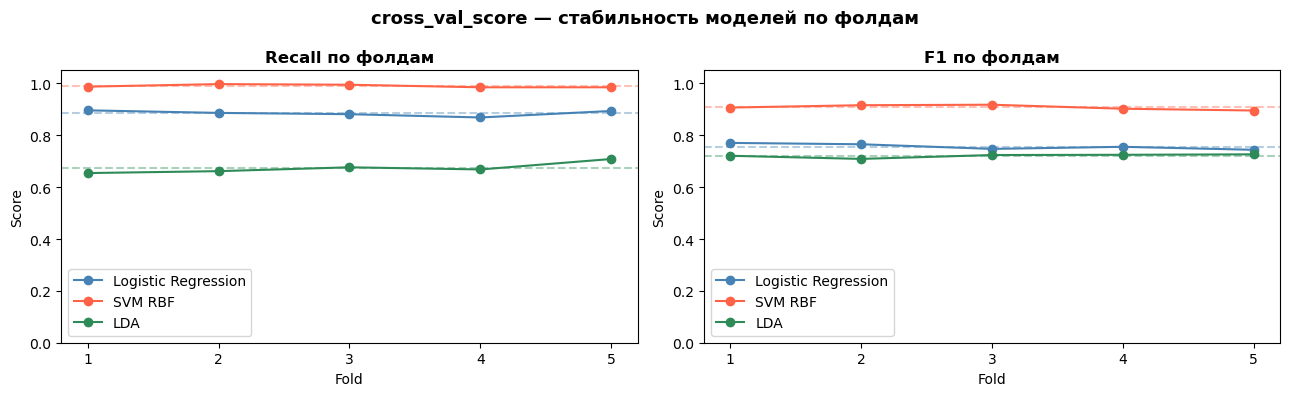

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Визуализируем Recall по каждому fold для каждой модели
# Это показывает стабильность — ровная линия лучше чем скачущая

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['steelblue', 'tomato', 'seagreen']

for ax, scoring, title in [
    (axes[0], 'recall', 'Recall по фолдам'),
    (axes[1], 'f1',     'F1 по фолдам'),
]:
    for (name, model), color in zip(models.items(), colors):
        scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring=scoring)
        ax.plot(range(1, 6), scores, marker='o', label=name, color=color)
        ax.axhline(scores.mean(), linestyle='--', alpha=0.4, color=color)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(range(1, 6))
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.suptitle('cross_val_score — стабильность моделей по фолдам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Визуализация границы решений SVM (через PCA)

PC1 объясняет: 44.6% дисперсии
PC2 объясняет: 20.6% дисперсии
Итого:         65.3% дисперсии сохранено


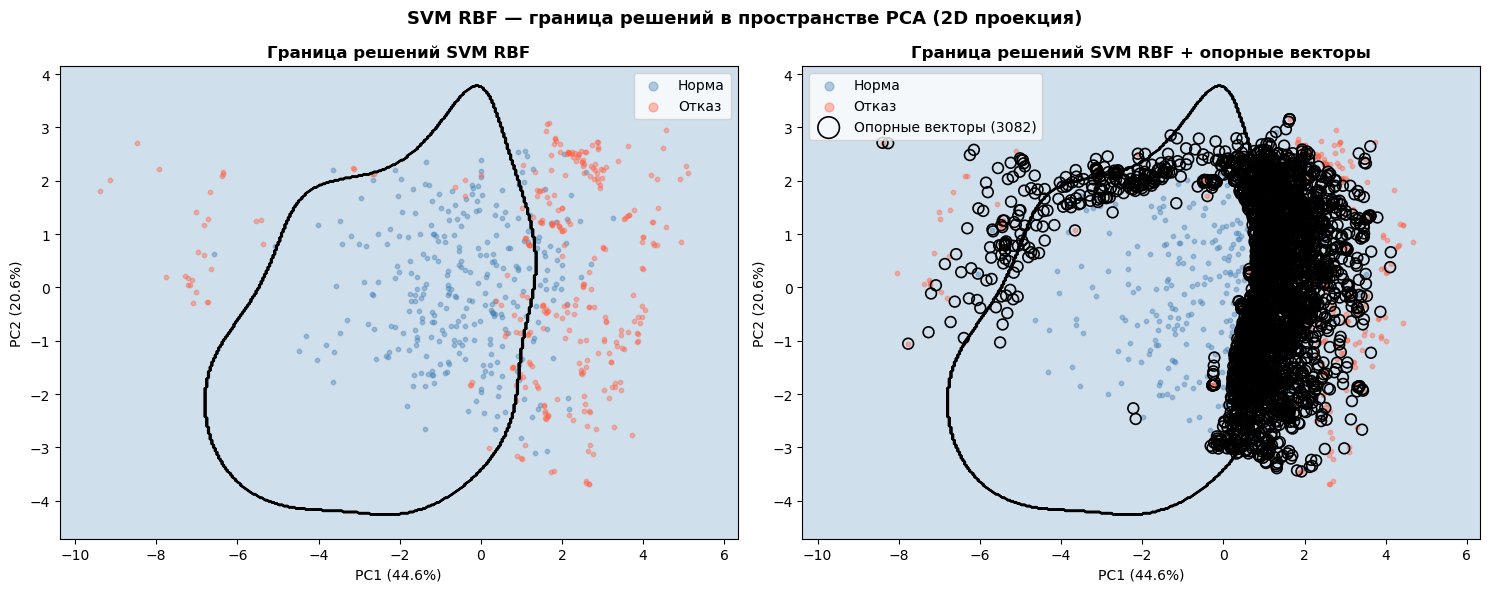

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Визуализировать SVM в 8D невозможно — человеческий глаз видит максимум 3D.
# PCA сжимает 8 признаков до 2 главных компонент — направлений максимальной дисперсии.
# Граница будет приближённой (часть информации теряется), но даёт интуитивное понимание
# как SVM разделил пространство.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_res)
explained = pca.explained_variance_ratio_

print(f"PC1 объясняет: {explained[0]*100:.1f}% дисперсии")
print(f"PC2 объясняет: {explained[1]*100:.1f}% дисперсии")
print(f"Итого:         {sum(explained)*100:.1f}% дисперсии сохранено")

# Обучаем SVM на 2D PCA для визуализации границы
svm_2d = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_2d.fit(X_pca, y_train_res)

# Сетка точек для отрисовки границы решений
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, show_sv, title in [
    (axes[0], False, "Граница решений SVM RBF"),
    (axes[1], True,  "Граница решений SVM RBF + опорные векторы"),
]:
    ax.contourf(xx, yy, Z, alpha=0.25, colors=["steelblue", "tomato"])
    ax.contour(xx, yy, Z, colors="black", linewidths=1.2)

    idx_norm = np.where(y_train_res == 0)[0]
    idx_fail = np.where(y_train_res == 1)[0]
    sample_n = np.random.choice(idx_norm, size=min(300, len(idx_norm)), replace=False)
    sample_f = np.random.choice(idx_fail, size=min(300, len(idx_fail)), replace=False)

    ax.scatter(X_pca[sample_n, 0], X_pca[sample_n, 1], c="steelblue", s=10, alpha=0.4, label="Норма")
    ax.scatter(X_pca[sample_f, 0], X_pca[sample_f, 1], c="tomato",    s=10, alpha=0.4, label="Отказ")

    if show_sv:
        sv = svm_2d.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors="none", edgecolors="black",
                   linewidths=1.2, label=f"Опорные векторы ({len(sv)})")

    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(markerscale=2)

plt.suptitle("SVM RBF — граница решений в пространстве PCA (2D проекция)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

PC1: 44.6%  PC2: 20.6%  PC3: 17.3%
Итого сохранено: 82.5% дисперсии


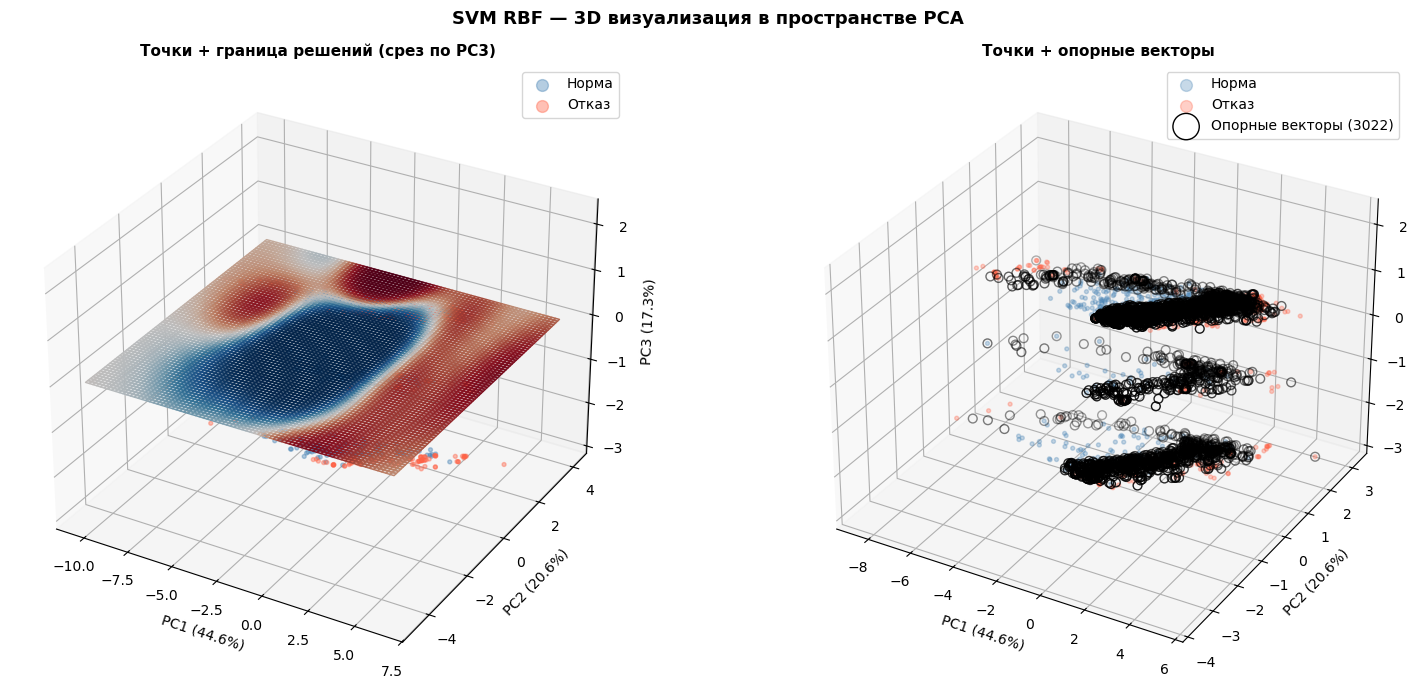

In [19]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# 3D визуализация — сжимаем 8 признаков до 3 главных компонент
# Граница в 3D точнее чем в 2D — больше информации сохраняется

pca_3d = PCA(n_components=3, random_state=42)
X_pca3 = pca_3d.fit_transform(X_train_res)
explained_3d = pca_3d.explained_variance_ratio_

print(f"PC1: {explained_3d[0]*100:.1f}%  PC2: {explained_3d[1]*100:.1f}%  PC3: {explained_3d[2]*100:.1f}%")
print(f"Итого сохранено: {sum(explained_3d)*100:.1f}% дисперсии")

svm_3d = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_3d.fit(X_pca3, y_train_res)

idx_norm = np.where(y_train_res == 0)[0]
idx_fail = np.where(y_train_res == 1)[0]
sample_n = np.random.choice(idx_norm, size=min(400, len(idx_norm)), replace=False)
sample_f = np.random.choice(idx_fail, size=min(400, len(idx_fail)), replace=False)

x_min, x_max = X_pca3[:, 0].min() - 1, X_pca3[:, 0].max() + 1
y_min, y_max = X_pca3[:, 1].min() - 1, X_pca3[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),
                     np.linspace(y_min, y_max, 80))

pc3_mean = X_pca3[:, 2].mean()
grid_points = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, pc3_mean)]
Z_prob = svm_3d.predict_proba(grid_points)[:, 1].reshape(xx.shape)

fig = plt.figure(figsize=(16, 7))

# График 1: точки + поверхность границы
ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(xx, yy,
                        np.full_like(xx, pc3_mean),
                        facecolors=plt.cm.RdBu_r(Z_prob),
                        alpha=0.35, rstride=1, cstride=1)
ax1.scatter(X_pca3[sample_n, 0], X_pca3[sample_n, 1], X_pca3[sample_n, 2],
            c="steelblue", s=8, alpha=0.4, label="Норма")
ax1.scatter(X_pca3[sample_f, 0], X_pca3[sample_f, 1], X_pca3[sample_f, 2],
            c="tomato", s=8, alpha=0.4, label="Отказ")
ax1.set_xlabel(f"PC1 ({explained_3d[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({explained_3d[1]*100:.1f}%)")
ax1.set_zlabel(f"PC3 ({explained_3d[2]*100:.1f}%)")
ax1.set_title("Точки + граница решений (срез по PC3)", fontsize=11, fontweight="bold")
ax1.legend(markerscale=3)

# График 2: опорные векторы
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X_pca3[sample_n, 0], X_pca3[sample_n, 1], X_pca3[sample_n, 2],
            c="steelblue", s=8, alpha=0.3, label="Норма")
ax2.scatter(X_pca3[sample_f, 0], X_pca3[sample_f, 1], X_pca3[sample_f, 2],
            c="tomato", s=8, alpha=0.3, label="Отказ")
sv = svm_3d.support_vectors_
ax2.scatter(sv[:, 0], sv[:, 1], sv[:, 2],
            s=40, facecolors="none", edgecolors="black",
            linewidths=1.0, label=f"Опорные векторы ({len(sv)})")
ax2.set_xlabel(f"PC1 ({explained_3d[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({explained_3d[1]*100:.1f}%)")
ax2.set_zlabel(f"PC3 ({explained_3d[2]*100:.1f}%)")
ax2.set_title("Точки + опорные векторы", fontsize=11, fontweight="bold")
ax2.legend(markerscale=3)

plt.suptitle("SVM RBF — 3D визуализация в пространстве PCA",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Этап                             Строк   Столбцов
--------------------------------------------------
Исходный датасет                  9973         10
После Feature Engineering         9973         13
После удаления столбцов           9973          9
После One-Hot Encoding            9973          9
Train (до SMOTE)                  6980          8
Train (после SMOTE)               8773          8
Validation                        1497          8
Test                              1496          8

Признак                   Происхождение        Тип   Описание
------------------------------------------------------------------------------
Rotational speed [rpm]         Исходный   Числовой   Скорость вращения шпинделя
Torque [Nm]                    Исходный   Числовой   Крутящий момент
Tool wear [min]                Исходный   Числовой   Износ инструмента
temp_diff                         Новый   Числовой   Process temp − Air temp
power                             Новый   Числовой   Rotatio

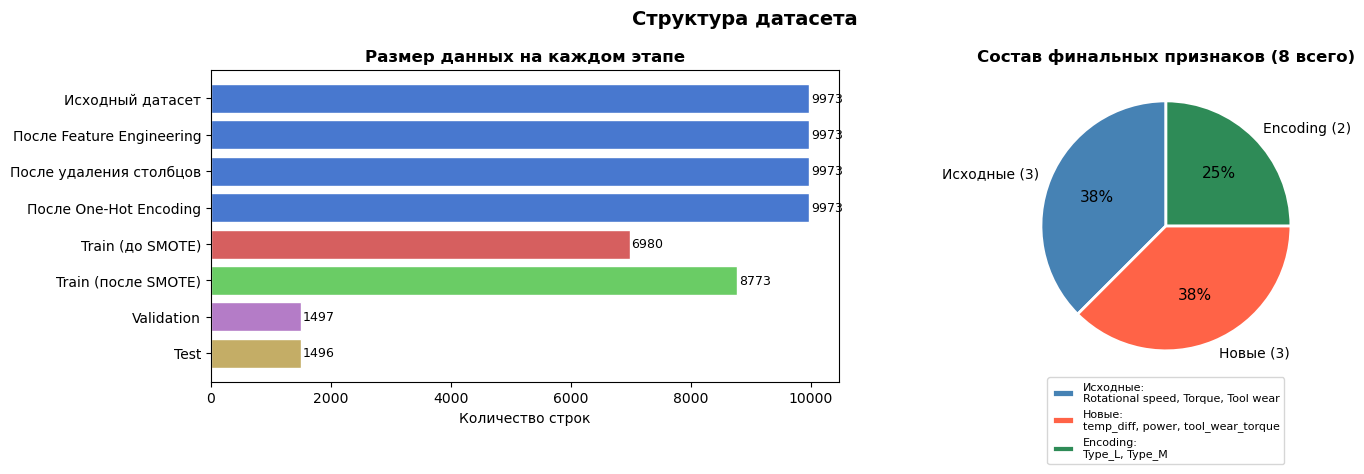

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Форма данных на каждом этапе ──────────────────────────────────────────
stages = {
    "Исходный датасет":          (9973, 10),
    "После Feature Engineering": (9973, 13),
    "После удаления столбцов":   (9973,  9),
    "После One-Hot Encoding":    (9973,  9),
    "Train (до SMOTE)":          (len(y_train), 8),
    "Train (после SMOTE)":       (len(y_train_res), 8),
    "Validation":                (len(y_val), 8),
    "Test":                      (len(y_test), 8),
}

print(f"{'Этап':<30} {'Строк':>7} {'Столбцов':>10}")
print("-" * 50)
for name, (rows, cols) in stages.items():
    print(f"{name:<30} {rows:>7} {cols:>10}")

# ── 2. Признаки финального датасета ──────────────────────────────────────────
print(f"\n{'Признак':<25} {'Происхождение':>13} {'Тип':>10}   Описание")
print("-" * 78)
feature_info = [
    ("Rotational speed [rpm]", "Исходный",  "Числовой", "Скорость вращения шпинделя"),
    ("Torque [Nm]",            "Исходный",  "Числовой", "Крутящий момент"),
    ("Tool wear [min]",        "Исходный",  "Числовой", "Износ инструмента"),
    ("temp_diff",              "Новый",     "Числовой", "Process temp − Air temp"),
    ("power",                  "Новый",     "Числовой", "Rotational speed × Torque"),
    ("tool_wear_torque",       "Новый",     "Числовой", "Tool wear × Torque"),
    ("Type_L",                 "Encoding",  "Бинарный", "Тип продукта L (0/1)"),
    ("Type_M",                 "Encoding",  "Бинарный", "Тип продукта M (0/1)"),
]
for feat, origin, dtype, desc in feature_info:
    print(f"{feat:<25} {origin:>13} {dtype:>10}   {desc}")

# ── 3. Визуализация ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: строки на каждом этапе
colors_bar = ["#4878cf","#4878cf","#4878cf","#4878cf","#d65f5f","#6acc65","#b47cc7","#c4ad66"]
stage_names = list(stages.keys())
stage_rows  = [v[0] for v in stages.values()]

bars = axes[0].barh(stage_names, stage_rows, color=colors_bar, edgecolor="white")
for bar, val in zip(bars, stage_rows):
    axes[0].text(val + 30, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=9)
axes[0].set_xlabel("Количество строк")
axes[0].set_title("Размер данных на каждом этапе", fontsize=12, fontweight="bold")
axes[0].invert_yaxis()

# График 2: состав признаков по происхождению
origins = ["Исходные (3)", "Новые (3)", "Encoding (2)"]
counts  = [3, 3, 2]
colors_pie = ["steelblue", "tomato", "seagreen"]
wedges, texts, autotexts = axes[1].pie(
    counts, labels=origins, autopct="%1.0f%%",
    colors=colors_pie, startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)

labels_detail = [
    "Исходные:\nRotational speed, Torque, Tool wear",
    "Новые:\ntemp_diff, power, tool_wear_torque",
    "Encoding:\nType_L, Type_M",
]
axes[1].legend(wedges, labels_detail, loc="lower center",
               bbox_to_anchor=(0.5, -0.28), fontsize=8)
axes[1].set_title("Состав финальных признаков (8 всего)", fontsize=12, fontweight="bold")

plt.suptitle("Структура датасета", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Этап 8. Pipeline + GridSearchCV

In [29]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score, make_scorer

# Pipeline объединяет StandardScaler + SMOTE + модель в один объект.
#
# Зачем Pipeline:
#   Без Pipeline нужно вручную следить за порядком шагов при каждом предсказании.
#   Pipeline гарантирует: SMOTE применяется только внутри каждого fold при fit,
#   при predict — только scaler+модель (SMOTE пропускается автоматически).
#   В Web-приложении достаточно одного вызова pipeline.predict(raw_data).
#
# Используем imblearn.Pipeline (не sklearn.Pipeline) — он умеет работать со SMOTE.
# StandardScaler внутри Pipeline: fit происходит на каждом train-fold внутри CV,
# transform применяется к val-fold — data leakage исключён.
#
# Параметры GridSearchCV:
#   C     — штраф за ошибку. Большой C → жёсткая граница → меньше FP → лучше Precision.
#   gamma — радиус влияния точки при RBF. Маленький → гладкая граница.
#   sampling_strategy — соотношение minority/majority после SMOTE.
#                       Меньше синтетики → модель осторожнее → лучше Precision.
#
# scoring=f2_scorer — F-beta с beta=2: Recall важнее Precision в 2 раза.
# Это формализует задачу: пропуск отказа стоит дороже ложной тревоги,
# но Precision тоже учитывается — в отличие от чистого Recall.
# Конкретный порог Recall мы задаём дополнительно при выборе threshold.

f2_scorer = make_scorer(fbeta_score, beta=2)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  BorderlineSMOTE(kind='borderline-2', k_neighbors=5, random_state=42)),
    ('svm',    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
])

param_grid = {
    'smote__sampling_strategy': [0.1, 0.15, 0.2, 0.3, 0.5],
    'svm__C':                   [0.1, 1, 10, 100],
    'svm__gamma':               ['scale', 0.1, 0.01, 0.001],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True
)

# GridSearch обучается на сырых (нeмасштабированных) данных — scaler внутри Pipeline
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший F2 (CV):   {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Лучшие параметры: {'smote__sampling_strategy': 0.5, 'svm__C': 100, 'svm__gamma': 0.1}
Лучший F2 (CV):   0.7390


Оптимальный порог: 0.451
При этом пороге — Recall: 0.8571, Precision: 0.5753

=== Результаты на Validation ===
Recall:    0.8571   (минимум: ≥ 0.85)
Precision: 0.5753
F1:        0.6885
ROC-AUC:   0.9627

              precision    recall  f1-score   support

       Норма       1.00      0.98      0.99      1448
       Отказ       0.58      0.86      0.69        49

    accuracy                           0.97      1497
   macro avg       0.79      0.92      0.84      1497
weighted avg       0.98      0.97      0.98      1497



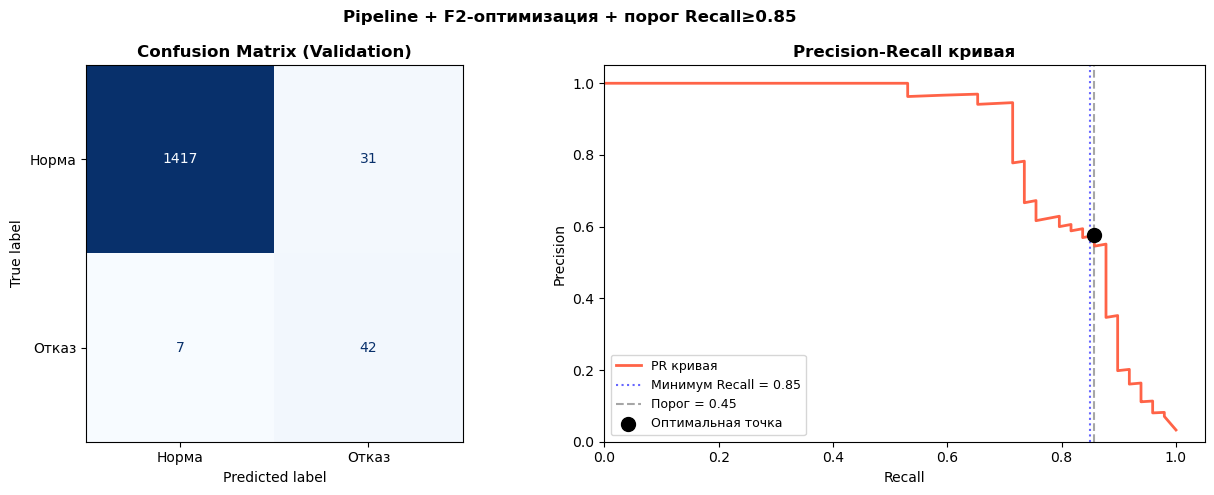

In [30]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             f1_score, recall_score, precision_score, roc_auc_score)
import matplotlib.pyplot as plt
import numpy as np

# Вероятности лучшей модели на validation (сырые данные — scaler внутри Pipeline)
y_prob_val = best_pipeline.predict_proba(X_val)[:, 1]

# Поиск оптимального порога.
# Ищем точку где Recall >= 0.85 и Precision максимальна.
# 0.85 — разумный минимум: пропускаем не больше 15% реальных отказов,
# при этом оставляем модели пространство для достойного Precision.
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_prob_val)

best_threshold = 0.5
best_precision = 0.0
for thr, prec, rec in zip(thresholds, precision_vals[:-1], recall_vals[:-1]):
    if rec >= 0.85 and prec > best_precision:
        best_precision = prec
        best_threshold = thr

idx = np.searchsorted(thresholds, best_threshold)
print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"При этом пороге — Recall: {recall_vals[idx]:.4f}, "
      f"Precision: {precision_vals[idx]:.4f}")

# Применяем найденный порог
y_pred_val = (y_prob_val >= best_threshold).astype(int)

print("\n=== Результаты на Validation ===")
print(f"Recall:    {recall_score(y_val, y_pred_val):.4f}   (минимум: ≥ 0.85)")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_val):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_prob_val):.4f}")
print()
print(classification_report(y_val, y_pred_val, target_names=["Норма", "Отказ"]))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Норма", "Отказ"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Validation)", fontsize=12, fontweight="bold")

# Precision-Recall кривая
axes[1].plot(recall_vals, precision_vals, color="tomato", linewidth=2, label="PR кривая")
axes[1].axvline(0.85, color="blue", linestyle=":", alpha=0.6, label="Минимум Recall = 0.85")
axes[1].axvline(recall_score(y_val, y_pred_val), color="gray", linestyle="--",
                alpha=0.7, label=f"Порог = {best_threshold:.2f}")
axes[1].scatter(recall_score(y_val, y_pred_val), precision_score(y_val, y_pred_val),
                color="black", s=100, zorder=5, label="Оптимальная точка")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall кривая", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)

plt.suptitle("Pipeline + F2-оптимизация + порог Recall≥0.85",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Этап 9. Финальная оценка на Test

   ФИНАЛЬНЫЕ МЕТРИКИ НА TEST (одноразово)
  Recall:    0.8200
  Precision: 0.6029
  F1:        0.6949
  ROC-AUC:   0.9777
  Порог:     0.451

              precision    recall  f1-score   support

       Норма       0.99      0.98      0.99      1446
       Отказ       0.60      0.82      0.69        50

    accuracy                           0.98      1496
   macro avg       0.80      0.90      0.84      1496
weighted avg       0.98      0.98      0.98      1496



/home/kif1r4ek/conda-envs/ml-dl/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


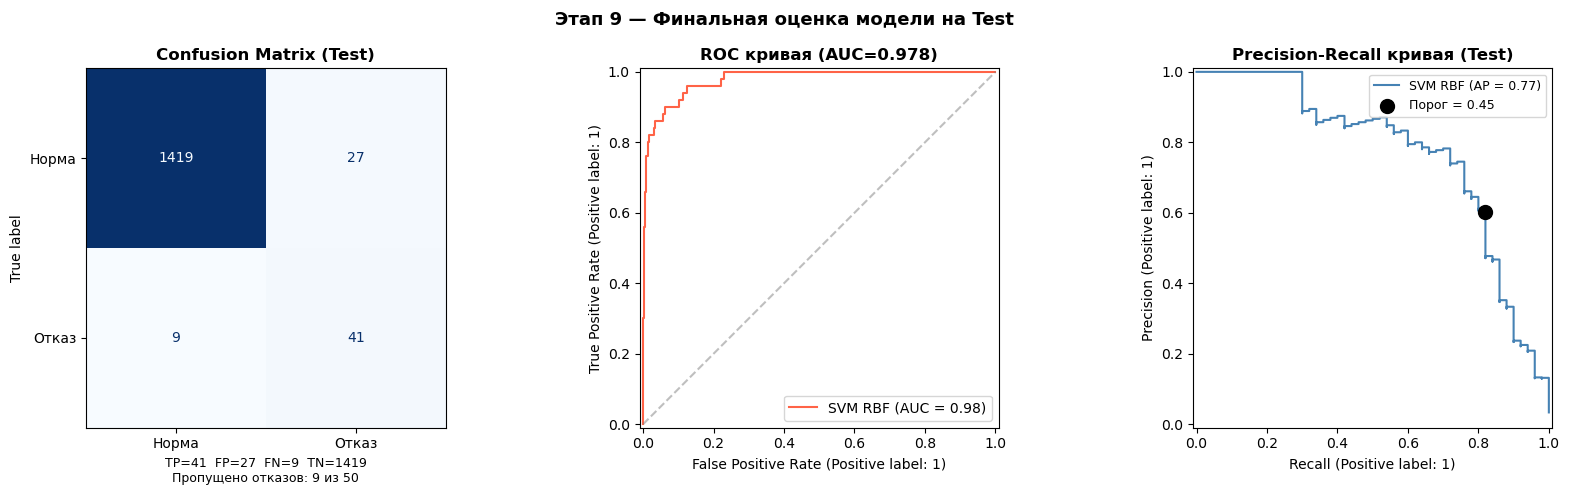

In [31]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             f1_score, recall_score, precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import numpy as np

# Финальная оценка — касаемся test ТОЛЬКО ОДИН РАЗ.
#
# До этого момента test был полностью изолирован:
#   - StandardScaler (внутри Pipeline) обучен только на train-fold-ах
#   - SMOTE применялся только на train (внутри Pipeline)
#   - Все решения (выбор модели, гиперпараметры, порог) принимались по val
#
# Результат на test — честная оценка того как модель работает на реальных
# новых данных. Если метрики близки к val — модель обобщает хорошо и не переобучена.

y_prob_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

rec  = recall_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)
auc  = roc_auc_score(y_test, y_prob_test)

print("=" * 45)
print("   ФИНАЛЬНЫЕ МЕТРИКИ НА TEST (одноразово)")
print("=" * 45)
print(f"  Recall:    {rec:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  ROC-AUC:   {auc:.4f}")
print(f"  Порог:     {best_threshold:.3f}")
print("=" * 45)
print()
print(classification_report(y_test, y_pred_test, target_names=["Норма", "Отказ"]))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Норма", "Отказ"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
tn, fp, fn, tp = cm.ravel()
axes[0].set_title("Confusion Matrix (Test)", fontsize=12, fontweight="bold")
axes[0].set_xlabel(
    f"TP={tp}  FP={fp}  FN={fn}  TN={tn}\n"
    f"Пропущено отказов: {fn} из {tp + fn}",
    fontsize=9
)

# ROC кривая
RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1],
                                  name="SVM RBF", color="tomato")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
axes[1].set_title(f"ROC кривая (AUC={auc:.3f})", fontsize=12, fontweight="bold")

# Precision-Recall кривая
PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[2],
                                         name="SVM RBF", color="steelblue")
axes[2].scatter(rec, prec, color="black", s=100, zorder=5,
                label=f"Порог = {best_threshold:.2f}")
axes[2].legend(fontsize=9)
axes[2].set_title("Precision-Recall кривая (Test)", fontsize=12, fontweight="bold")

plt.suptitle("Этап 9 — Финальная оценка модели на Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Этап 10. Сохранение модели

In [ ]:
import joblib
import os

# Сохраняем два объекта в один файл — всё что нужно Web-приложению:
#
#   pipeline       — imblearn.Pipeline (StandardScaler + SMOTE + SVM RBF).
#                    StandardScaler внутри: Web-приложение передаёт сырые данные,
#                    Pipeline сам масштабирует и делает предсказание.
#                    При predict SMOTE не применяется — только scaler+SVM.
#                    Один вызов pipeline.predict_proba(raw_data) заменяет весь inference.
#
#   threshold      — оптимальный порог найденный на validation.
#                    Если predict_proba >= threshold → "Отказ", иначе → "Норма".
#
# Почему один файл, а не два:
#   Web-приложению нужно одно обращение к диску при старте сервера.
#   Pipeline и threshold версионируются вместе — нет риска использовать
#   threshold от одной версии модели с pipeline от другой.

os.makedirs('models', exist_ok=True)

model_bundle = {
    'pipeline':  best_pipeline,
    'threshold': best_threshold,
}

joblib.dump(model_bundle, 'models/binary_model.pkl')

# Проверка — загружаем обратно и делаем тестовое предсказание на сырых данных
loaded = joblib.load('models/binary_model.pkl')

proba = loaded['pipeline'].predict_proba(X_test.iloc[:3])[:, 1]
pred  = (proba >= loaded['threshold']).astype(int)

size_kb = os.path.getsize('models/binary_model.pkl') / 1024

print(f"Файл сохранён: models/binary_model.pkl  ({size_kb:.1f} KB)")
print(f"\nСодержимое bundle:")
print(f"  pipeline:  {type(loaded['pipeline']).__name__}  "
      f"(шаги: {[s[0] for s in loaded['pipeline'].steps]})")
print(f"  threshold: {loaded['threshold']:.3f}")
print(f"\nТестовое предсказание на 3 строках из test (сырые данные):")
print(f"  Вероятности отказа: {proba.round(3)}")
print(f"  Предсказание (0=Норма, 1=Отказ): {pred}")
print(f"  Реальные метки:                  {y_test.iloc[:3].values}")
print(f"\nМодель готова к деплою в Web-приложение.")